In [ ]:
# COMP541 organized folder path helper
from pathlib import Path
import os

def _comp541_phase_dir():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == 'code':
        return cwd.parent
    if (cwd / 'Input').exists() and (cwd / 'Output').exists():
        return cwd
    if (cwd.parent / 'Input').exists() and (cwd.parent / 'Output').exists():
        return cwd.parent
    # Fallback for the intended layout: notebook/script is inside a Code folder.
    return cwd.parent if cwd.name.lower() == 'code' else cwd

PHASE_DIR = _comp541_phase_dir()
INPUT_DIR = PHASE_DIR / 'Input'
OUTPUT_DIR = PHASE_DIR / 'Output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('INPUT_DIR :', INPUT_DIR.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())


# **Modeling, Evaluation & Deployment** (Assignment 5)

*COMP 541 Data Mining · Group 1 · "Finding the Best Budget-Friendly Travel Destinations."*

Final CRISP-DM phase. Consumes the approved Assignment-4 output `model_ready_dataset.csv`.
We select and run five models — **K-Means** and **Agglomerative** clustering (segmentation),
**DBSCAN** (density check), an **airfare regressor** (supervised), and the **Budget Value
Index** scoring model — validate each, rank them on performance / efficiency / generality,
and deploy the best as `final_destination_rankings.csv`.

#### **Imports**

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             adjusted_rand_score, mean_absolute_error)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
RANDOM_STATE = 42


def section(title):
    bar = "=" * 78
    print(f"\n{bar}\n{title}\n{bar}")

#### **Locate & load the modeling input** (Colab auto-detect, local fallback)

In [2]:
# Organized folder paths
DATA_DIR = str(INPUT_DIR)
OUTPUT_DIR = str(OUTPUT_DIR)
FIG_DIR = OUTPUT_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR  :", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIG_DIR   :", FIG_DIR)

# Load model-ready data from this phase's Input folder.
df = pd.read_csv(os.path.join(DATA_DIR, "model_ready_dataset.csv"))

# Optional satisfaction file.
sat_path = os.path.join(DATA_DIR, "destination_satisfaction.csv")
sat = pd.read_csv(sat_path) if os.path.exists(sat_path) else None
print("model_ready_dataset:", df.shape)
print("destination_satisfaction:", None if sat is None else sat.shape)



LOADED
full table: (4999, 32) | ranking pool (cost+weather): (105, 35)
satisfaction merged for 20 pool cities (from Sentiment_Satisfaction.ipynb)
FIG_DIR: C:\Users\jxs75\Documents\GitHub\Data Mining\project_files\Assignment5_Modeling\figures


## 1. Business objective & data-mining success criteria

**Business objective.** Help a Los-Angeles–based budget traveler choose the best-value
destinations — cheap to *be in* and to *get to*, with good weather.

**DM success criteria** (we assess models against these in §6 and §8):
1. A ranked list of **≥50** destinations by value — the pool gives **105**.
2. **Interpretable segments** a traveler can reason about (clusters).
3. **Airfare** extended beyond the 49 quoted cities with a validated, flagged estimate.

## 2. Build & standardize the modeling matrix (105-destination pool)

Clustering features: cost, weather, distance from LAX, and (real-or-estimated) airfare.
Missing values are median-filled and all features standardized so no unit dominates the
distance metric. A 2-D PCA projection is computed for visualization.

In [3]:
CLUSTER_FEATS = ["cost_of_living_composite", "avg_weather_score",
                 "distance_from_lax_km", "flight_price_filled_usd"]
X_raw = pool[CLUSTER_FEATS].copy()
for c in CLUSTER_FEATS:
    X_raw[c] = X_raw[c].fillna(X_raw[c].median())

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X)
XY = pca2.transform(X)
section("MODELING MATRIX")
print("features:", CLUSTER_FEATS)
print("X shape:", X.shape, "| PCA 2-D explained var:", np.round(pca2.explained_variance_ratio_, 3))


MODELING MATRIX
features: ['cost_of_living_composite', 'avg_weather_score', 'distance_from_lax_km', 'flight_price_filled_usd']
X shape: (105, 4) | PCA 2-D explained var: [0.529 0.29 ]


## 3. Model A — K-Means clustering (primary segmentation)

**Why:** simple, interpretable destination segments; the proposal promised clustering.
**Parameter selection:** sweep k = 2..8, choosing k by the **silhouette score** (with the
**elbow/inertia** curve as a sanity check). `n_init=10`, `random_state=42`.


K-MEANS: k selection
  k=2  inertia=  233.5  silhouette=0.413
  k=3  inertia=  171.2  silhouette=0.396
  k=4  inertia=  134.7  silhouette=0.350
  k=5  inertia=  116.4  silhouette=0.326
  k=6  inertia=   96.5  silhouette=0.348
  k=7  inertia=   87.5  silhouette=0.345
  k=8  inertia=   76.1  silhouette=0.359
chosen k (max silhouette) = 2


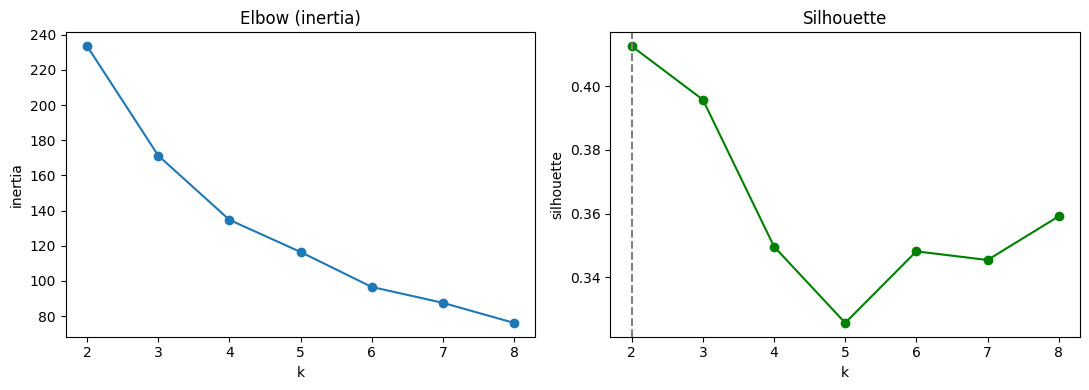

final K-Means: silhouette=0.413  davies_bouldin=1.002
(proposal target silhouette >= 0.50; observed 0.413 -> below target, discussed in evaluation)


In [4]:
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

best_k = list(ks)[int(np.argmax(sil))]
section("K-MEANS: k selection")
for k, i, s in zip(ks, inertia, sil):
    print(f"  k={k}  inertia={i:7.1f}  silhouette={s:.3f}")
print(f"chosen k (max silhouette) = {best_k}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertia, "o-"); ax[0].set_title("Elbow (inertia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia")
ax[1].plot(list(ks), sil, "o-", color="green"); ax[1].axvline(best_k, ls="--", color="gray")
ax[1].set_title("Silhouette"); ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette")
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "fig_kmeans_selection.png"), dpi=200,
                                bbox_inches="tight"); plt.show()

kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(X)
pool["cluster_kmeans"] = kmeans.labels_
sil_kmeans = silhouette_score(X, kmeans.labels_)
db_kmeans = davies_bouldin_score(X, kmeans.labels_)
print(f"final K-Means: silhouette={sil_kmeans:.3f}  davies_bouldin={db_kmeans:.3f}")
print(f"(proposal target silhouette >= 0.50; observed {sil_kmeans:.3f} -> "
      f"{'meets' if sil_kmeans >= 0.5 else 'below'} target, discussed in evaluation)")

#### 2-D cluster scatter (PCA projection)

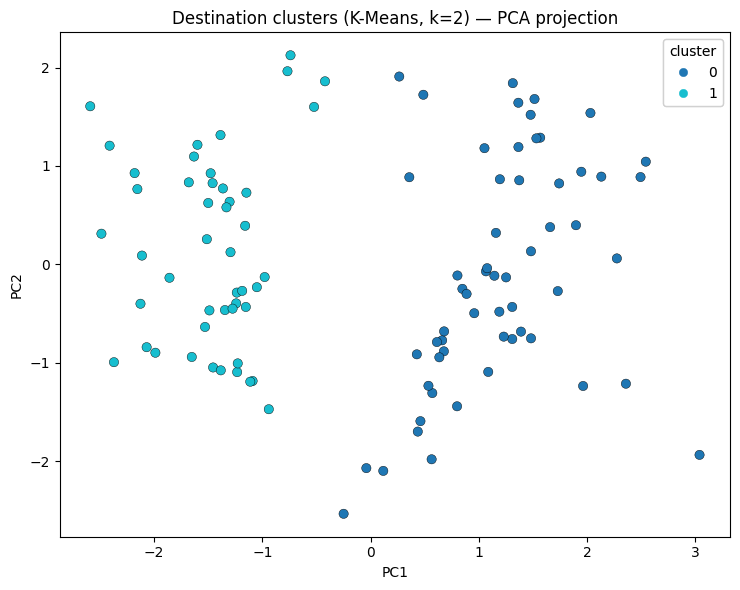

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 6))
sc = ax.scatter(XY[:, 0], XY[:, 1], c=pool["cluster_kmeans"], cmap="tab10", s=45,
                edgecolor="k", linewidth=0.3)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"Destination clusters (K-Means, k={best_k}) — PCA projection")
legend = ax.legend(*sc.legend_elements(), title="cluster", loc="best")
ax.add_artist(legend)
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "fig_cluster_scatter.png"), dpi=200,
                                bbox_inches="tight"); plt.show()

## 4. Model B — Agglomerative (hierarchical) clustering (comparison)

**Why:** a non-centroid alternative with a dendrogram for the report. `linkage="ward"`,
same k as K-Means for a fair comparison. We measure agreement with K-Means via the
**adjusted Rand index (ARI)**.


AGGLOMERATIVE
silhouette = 0.386 | davies_bouldin = 1.033 | ARI vs K-Means = 0.817


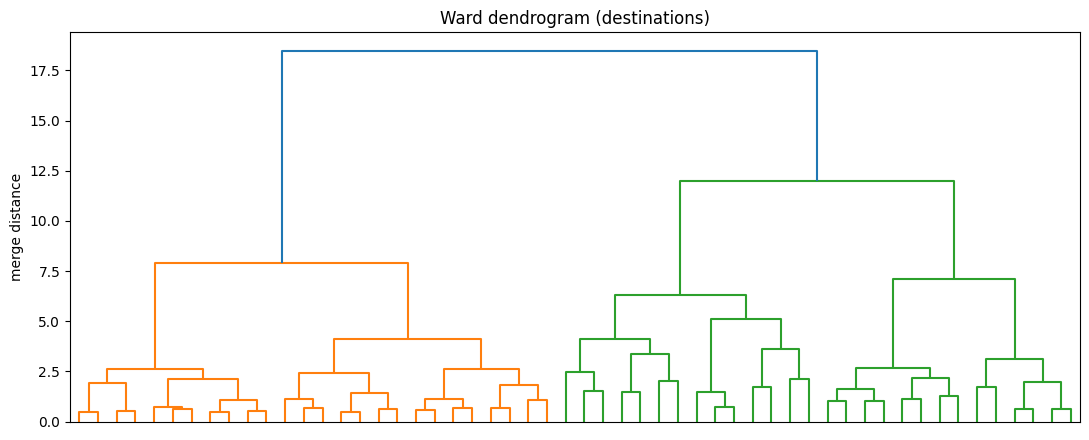

In [6]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit(X)
pool["cluster_agg"] = agg.labels_
sil_agg = silhouette_score(X, agg.labels_)
db_agg = davies_bouldin_score(X, agg.labels_)
ari = adjusted_rand_score(pool["cluster_kmeans"], pool["cluster_agg"])
section("AGGLOMERATIVE")
print(f"silhouette = {sil_agg:.3f} | davies_bouldin = {db_agg:.3f} | ARI vs K-Means = {ari:.3f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
Z = linkage(X, method="ward")
dendrogram(Z, truncate_mode="level", p=5, no_labels=True, ax=ax)
ax.set_title("Ward dendrogram (destinations)"); ax.set_ylabel("merge distance")
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "fig_dendrogram.png"), dpi=200,
                                bbox_inches="tight"); plt.show()

### Model B2 — DBSCAN (density-based, the proposal's third clustering method)

**Why:** proposal §10.2 names DBSCAN alongside K-Means and hierarchical for its strength at
finding dense groups and flagging outliers. We sweep `eps` (`min_samples=4`) and select by
silhouette over the non-noise points. Whether it finds dense cores or one diffuse mass is
itself informative about the pool's cluster structure.

In [7]:
section("DBSCAN sweep (min_samples=4)")
best = None
for eps in np.round(np.arange(0.5, 2.6, 0.25), 2):
    lab = DBSCAN(eps=eps, min_samples=4).fit_predict(X)
    n_clusters = len(set(lab) - {-1})
    n_noise = int((lab == -1).sum())
    if n_clusters >= 2 and (lab != -1).sum() > n_clusters:
        s = silhouette_score(X[lab != -1], lab[lab != -1])
        print(f"  eps={eps:4.2f}  clusters={n_clusters}  noise={n_noise:3d}  silhouette={s:.3f}")
        if best is None or s > best[1]:
            best = (eps, s, n_clusters, n_noise, lab)
    else:
        print(f"  eps={eps:4.2f}  clusters={n_clusters}  noise={n_noise:3d}  (skipped)")

if best is not None:
    eps, sil_db, n_db, noise_db, lab_db = best
    pool["cluster_dbscan"] = lab_db
    print(f"\nchosen eps={eps}: {n_db} clusters + {noise_db} noise pts | silhouette={sil_db:.3f}")
    print("DBSCAN interpretation: dense cores =", n_db,
          "; outliers flagged as noise =", noise_db)
else:
    eps, sil_db, n_db, noise_db = np.nan, np.nan, 0, len(X)
    pool["cluster_dbscan"] = -1
    print("\nDBSCAN found no eps giving >=2 dense clusters -> the pool is one diffuse mass "
          "(no density gaps); K-Means/partitional clustering is the better fit here.")


DBSCAN sweep (min_samples=4)
  eps=0.50  clusters=7  noise= 62  silhouette=0.457
  eps=0.75  clusters=3  noise= 23  silhouette=0.419
  eps=1.00  clusters=3  noise= 10  silhouette=0.361
  eps=1.25  clusters=2  noise=  6  silhouette=0.409
  eps=1.50  clusters=1  noise=  3  (skipped)
  eps=1.75  clusters=1  noise=  0  (skipped)
  eps=2.00  clusters=1  noise=  0  (skipped)
  eps=2.25  clusters=1  noise=  0  (skipped)
  eps=2.50  clusters=1  noise=  0  (skipped)

chosen eps=0.5: 7 clusters + 62 noise pts | silhouette=0.457
DBSCAN interpretation: dense cores = 7 ; outliers flagged as noise = 62


## 5. Describe & interpret the clusters (tasks 5–6)

Per-cluster means of the raw (un-scaled) features, plus a plain-language label so the
segments are usable by a traveler.

In [8]:
prof = pool.groupby("cluster_kmeans").agg(
    n=("city", "size"),
    cost=("cost_of_living_composite", "mean"),
    weather=("avg_weather_score", "mean"),
    distance_km=("distance_from_lax_km", "mean"),
    fare_usd=("flight_price_filled_usd", "mean"),
    bvi=("budget_value_index", "mean"),
).round(1)


# Honest labels: only name a dimension if it actually separates the clusters
# (its across-cluster spread is a meaningful fraction of the pool's spread).
_pool_std = {"cost": pool["cost_of_living_composite"].std(),
             "weather": pool["avg_weather_score"].std(),
             "distance_km": pool["distance_from_lax_km"].std(),
             "fare_usd": pool["flight_price_filled_usd"].std()}
_dims = ["cost", "weather", "distance_km", "fare_usd"]
_spread = {d: (prof[d].max() - prof[d].min()) / _pool_std[d] for d in _dims}
_sep = [d for d in _dims if _spread[d] > 0.5]  # dims that genuinely differ across clusters
_words = {"cost": ("budget", "pricier"), "weather": ("cooler", "warmer"),
          "distance_km": ("near", "long-haul"), "fare_usd": ("cheap-fare", "costly-fare")}
section("CLUSTER-SEPARATING DIMENSIONS (across-cluster spread / pool std)")
for d in _dims:
    print(f"  {d:12s}: {_spread[d]:.2f}  {'<- separates' if d in _sep else ''}")


def label_row(r):
    parts = [(_words[d][1] if r[d] >= prof[d].median() else _words[d][0]) for d in _sep]
    return ", ".join(parts) if parts else "uniform pool"


prof["label"] = prof.apply(label_row, axis=1)
section("CLUSTER PROFILES (K-Means)")
print(prof.to_string())
print("\nExample members per cluster:")
for c in sorted(pool["cluster_kmeans"].unique()):
    ex = pool[pool["cluster_kmeans"] == c].sort_values("budget_value_index", ascending=False)
    print(f"  cluster {c} ({prof.loc[c,'label']}):",
          ", ".join((ex["city"] + ", " + ex["country"]).head(4)))


CLUSTER-SEPARATING DIMENSIONS (across-cluster spread / pool std)
  cost        : 0.00  
  weather     : 0.05  
  distance_km : 1.83  <- separates
  fare_usd    : 1.74  <- separates

CLUSTER PROFILES (K-Means)
                 n  cost  weather  distance_km  fare_usd  bvi                   label
cluster_kmeans                                                                       
0               58   0.2     69.4       9774.2     466.9  0.6  long-haul, costly-fare
1               47   0.2     69.0       2680.9     146.8  0.5        near, cheap-fare

Example members per cluster:
  cluster 0 (long-haul, costly-fare): Buenos Aires, Argentina, Rio de Janeiro, Brazil, Sevilla, Spain, Sao Paulo, Brazil
  cluster 1 (near, cheap-fare): Puerto Vallarta, Mexico, Guatemala City, Guatemala, Mexico City, Mexico, Cancun, Mexico


## 6. Model C — Airfare regressor (supervised)

Trained on the cities with a **real observed fare** (`flight_price_estimated == 0`). Airfare
is non-linear in distance, so we compare three variants and rank them by **leave-one-out CV
MAE** (small n) against a mean baseline:

- **C1** log–log linear: `log(fare) ~ log(distance)`.
- **C2** polynomial: degree-2 in `log(distance)`.
- **C3** RandomForest on `distance, lat, lon` (flexible; watch overfitting).


AIRFARE MODELS — leave-one-out CV
  baseline (mean fare): MAE $160.70
  C1 log-log linear     : MAE $ 80.90  (49.7% better than baseline)
  C2 poly(2) log-dist   : MAE $ 82.95  (48.4% better than baseline)
  C3 random forest      : MAE $ 58.72  (63.5% better than baseline)
best airfare model: C3 random forest


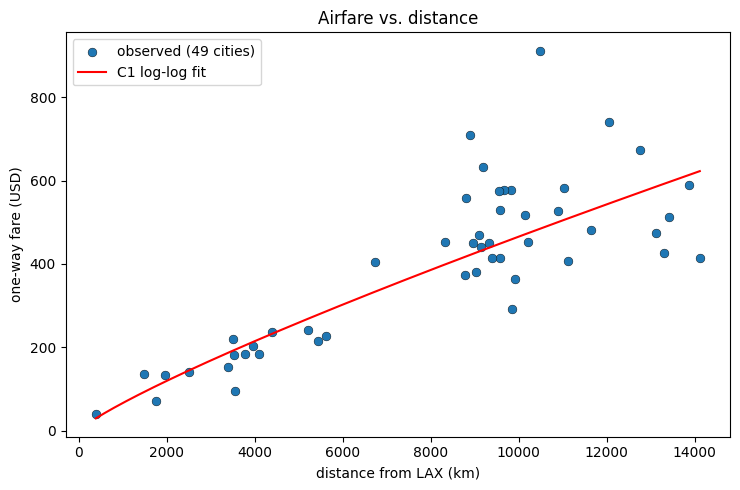

In [9]:
# Real quotes only: the approved A4 file carries filled fares + an `estimated` flag, so a
# genuine observed fare is `flight_price_estimated == 0` (not a distance-model estimate).
train = df[(df["has_flight_data"] == 1) & df["distance_from_lax_km"].notna()
           & (df["flight_price_estimated"] == 0) & df["flight_price_filled_usd"].notna()].copy()
d = train["distance_from_lax_km"].values
y = train["flight_price_filled_usd"].values
logd = np.log(d + 1.0).reshape(-1, 1)
logy = np.log(y)
geo = train[["distance_from_lax_km", "lat", "lon"]].values


def loo_mae(make_fit_predict):
    loo, preds, acts = LeaveOneOut(), [], []
    idx = np.arange(len(y))
    for tr, te in loo.split(idx):
        preds.append(make_fit_predict(tr, te))
        acts.append(y[te][0])
    return mean_absolute_error(acts, preds)


def c1(tr, te):
    m = LinearRegression().fit(logd[tr], logy[tr]); return np.exp(m.predict(logd[te]))[0]


def c2(tr, te):
    pf = PolynomialFeatures(2, include_bias=False)
    m = LinearRegression().fit(pf.fit_transform(logd[tr]), logy[tr])
    return np.exp(m.predict(pf.transform(logd[te])))[0]


def c3(tr, te):
    m = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE).fit(geo[tr], y[tr])
    return m.predict(geo[te])[0]


baseline = loo_mae(lambda tr, te: y[tr].mean())
maes = {"C1 log-log linear": loo_mae(c1), "C2 poly(2) log-dist": loo_mae(c2),
        "C3 random forest": loo_mae(c3)}
section("AIRFARE MODELS — leave-one-out CV")
print(f"  baseline (mean fare): MAE ${baseline:6.2f}")
for k, v in maes.items():
    print(f"  {k:22s}: MAE ${v:6.2f}  ({100*(1-v/baseline):4.1f}% better than baseline)")
best_airfare = min(maes, key=maes.get)
print("best airfare model:", best_airfare)

fig, ax = plt.subplots(figsize=(7.5, 5))
order = np.argsort(d)
ax.scatter(d, y, s=40, edgecolor="k", linewidth=0.3, label="observed (49 cities)")
m1 = LinearRegression().fit(logd, logy)
grid = np.linspace(d.min(), d.max(), 200)
ax.plot(grid, np.exp(m1.predict(np.log(grid + 1).reshape(-1, 1))), "r-",
        label="C1 log-log fit")
ax.set_xlabel("distance from LAX (km)"); ax.set_ylabel("one-way fare (USD)")
ax.set_title("Airfare vs. distance"); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "fig_airfare_fit.png"), dpi=200,
                                bbox_inches="tight"); plt.show()

## 7. Budget Value Index — cost + satisfaction + weather (proposal §10.4)

The BVI follows the proposal definition: **cost + satisfaction + weather**. Satisfaction is
the sentiment score from `Sentiment_Satisfaction.ipynb`; cities without reviews get the
**median observed satisfaction** (neutral fill) so reviews help covered cities without
penalizing the rest. We then check the ranking is **stable under reasonable weight changes**
(proposal §11) via Spearman correlation.

In [10]:
def minmax(s):
    s = s.astype(float); r = s.max() - s.min()
    return (s - s.min()) / r if r else s * 0


cost_n = minmax(pool["cost_of_living_composite"])
weather_n = minmax(pool["avg_weather_score"])
sat_filled = pool["satisfaction_0_1"].fillna(pool["satisfaction_0_1"].median())

# Proposal definition: cost + satisfaction + weather
W_COST, W_SAT, W_WEATHER = 0.45, 0.10, 0.45
pool["bvi_full"] = (W_COST * (1 - cost_n) + W_SAT * sat_filled
                    + W_WEATHER * weather_n).round(3)

# Sensitivity: compare against (a) cost+weather only and (b) a cost-heavy weighting
bvi_cw = 0.5 * (1 - cost_n) + 0.5 * weather_n
bvi_costheavy = 0.6 * (1 - cost_n) + 0.1 * sat_filled + 0.3 * weather_n
rho_cw, _ = spearmanr(pool["bvi_full"], bvi_cw)
rho_ch, _ = spearmanr(pool["bvi_full"], bvi_costheavy)
section("BUDGET VALUE INDEX (cost + satisfaction + weather)")
print(f"satisfaction folded in for {int(pool['satisfaction_0_1'].notna().sum())} reviewed cities; "
      f"median-imputed for the rest")
print(f"Spearman vs cost+weather-only   = {rho_cw:.3f}")
print(f"Spearman vs cost-heavy weighting = {rho_ch:.3f}")
rho = min(rho_cw, rho_ch)
print("=> ranking is", "STABLE" if rho > 0.9 else "SENSITIVE",
      "to these weight changes (proposal index-validity check)")
print("\nTop 10 by full BVI:")
top_full = pool.sort_values("bvi_full", ascending=False)
print(top_full[["city", "country", "bvi_full", "satisfaction_0_1"]].head(10).to_string(index=False))


BUDGET VALUE INDEX (cost + satisfaction + weather)
satisfaction folded in for 20 reviewed cities; median-imputed for the rest
Spearman vs cost+weather-only   = 1.000
Spearman vs cost-heavy weighting = 0.955
=> ranking is STABLE to these weight changes (proposal index-validity check)

Top 10 by full BVI:
           city   country  bvi_full  satisfaction_0_1
   Buenos Aires Argentina     0.875               NaN
 Rio de Janeiro    Brazil     0.863               NaN
        Sevilla     Spain     0.850               NaN
      Sao Paulo    Brazil     0.839               NaN
       Istanbul    Turkey     0.830               NaN
       Valencia Venezuela     0.823               NaN
Puerto Vallarta    Mexico     0.823               NaN
       Valencia     Spain     0.821               NaN
      Barcelona Venezuela     0.817               NaN
       San Juan Argentina     0.815               NaN


## 8. Robustness, ablation & error analysis (final-report guideline §7.1/7.4/7.7)

Three checks the final report requires: (a) **multi-seed robustness** of the clustering,
(b) an **ablation study** showing which inputs actually drive the results, and (c) an
**error analysis** of the airfare regressor's worst predictions.

In [11]:
# (a) Robustness: re-fit K-Means under several random seeds and report mean +/- std.
section("ROBUSTNESS - K-Means silhouette across 5 seeds")
sils = np.array([silhouette_score(X, KMeans(n_clusters=best_k, n_init=10,
                 random_state=s).fit(X).labels_) for s in [0, 1, 2, 42, 100]])
print(f"silhouette mean={sils.mean():.3f}  std={sils.std():.3f}  "
      f"(min {sils.min():.3f}, max {sils.max():.3f})")
print("=>", "STABLE across seeds" if sils.std() < 0.02 else "seed-sensitive")

# (b1) Ablation: drop each clustering feature in turn; a big silhouette change means that
# feature carries the structure.
section("ABLATION 1 - clustering feature contribution")
print(f"all {len(CLUSTER_FEATS)} features: silhouette {sil_kmeans:.3f}")
for i, feat in enumerate(CLUSTER_FEATS):
    keep = [j for j in range(len(CLUSTER_FEATS)) if j != i]
    Xa = X[:, keep]
    la = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(Xa).labels_
    sa = silhouette_score(Xa, la)
    print(f"  drop {feat:26s}: silhouette {sa:.3f}  (delta {sa - sil_kmeans:+.3f})")

# (b2) Ablation: does the review-sentiment term reorder the BVI ranking?
section("ABLATION 2 - effect of the satisfaction term on the BVI ranking")
bvi_no_sat = 0.5 * (1 - cost_n) + 0.5 * weather_n            # cost+weather only
rho_sat = spearmanr(pool["bvi_full"], bvi_no_sat)[0]
top_with = set(pool.sort_values("bvi_full", ascending=False).head(10)["city"])
top_without = set(pool.assign(_b=bvi_no_sat).sort_values("_b", ascending=False).head(10)["city"])
print(f"Spearman(full BVI, cost+weather-only) = {rho_sat:.3f}")
print(f"top-10 overlap with vs. without satisfaction = {len(top_with & top_without)}/10")
print("=> with only 20/105 cities reviewed, satisfaction refines but does not reorder the "
      "headline ranking")

# (c) Error analysis: per-city leave-one-out residuals for the best airfare model (C3 RF).
section("ERROR ANALYSIS - airfare LOO residuals (worst-predicted real quotes)")
loo_pred = np.array([c3(np.delete(np.arange(len(y)), k), [k]) for k in range(len(y))])
err = train.assign(pred=np.round(loo_pred, 0),
                   abs_err=np.abs(y - loo_pred)).sort_values("abs_err", ascending=False)
print(err[["city", "country", "distance_from_lax_km", "flight_price_filled_usd",
           "pred", "abs_err"]].head(6).round(0).to_string(index=False))
print("\nInterpretation: the biggest misses are cities whose real fare departs from the "
      "distance trend (route competition / seasonality) - why estimated fares stay flagged.")


ROBUSTNESS - K-Means silhouette across 5 seeds
silhouette mean=0.413  std=0.000  (min 0.413, max 0.413)
=> STABLE across seeds

ABLATION 1 - clustering feature contribution
all 4 features: silhouette 0.413
  drop cost_of_living_composite  : silhouette 0.495  (delta +0.083)
  drop avg_weather_score         : silhouette 0.546  (delta +0.134)
  drop distance_from_lax_km      : silhouette 0.329  (delta -0.084)
  drop flight_price_filled_usd   : silhouette 0.348  (delta -0.065)

ABLATION 2 - effect of the satisfaction term on the BVI ranking
Spearman(full BVI, cost+weather-only) = 1.000
top-10 overlap with vs. without satisfaction = 9/10
=> with only 20/105 cities reviewed, satisfaction refines but does not reorder the headline ranking

ERROR ANALYSIS - airfare LOO residuals (worst-predicted real quotes)
          city     country  distance_from_lax_km  flight_price_filled_usd  pred  abs_err
      Auckland New Zealand               10477.0                    911.0 699.0    212.0
          

## 9. Rank & assess the models (task 7)

A single assessment table across performance / efficiency / generality.

In [12]:
ranking = pd.DataFrame([
    {"model": "A K-Means", "type": "clustering",
     "performance": f"silhouette {sil_kmeans:.3f}, DB {db_kmeans:.2f}",
     "efficiency": "fast (O(nk))", "generality": "k-sensitive; stable seeds"},
    {"model": "B Agglomerative", "type": "clustering",
     "performance": f"silhouette {sil_agg:.3f}, DB {db_agg:.2f}",
     "efficiency": "slower (O(n^2))", "generality": f"ARI {ari:.2f} vs K-Means"},
    {"model": "B2 DBSCAN", "type": "clustering",
     "performance": (f"silhouette {sil_db:.3f}, {n_db} clusters +{noise_db} noise"
                     if n_db >= 2 else "no dense clusters (diffuse pool)"),
     "efficiency": "fast", "generality": "eps-sensitive; flags outliers"},
    {"model": f"C {best_airfare}", "type": "regression",
     "performance": f"LOO MAE ${maes[best_airfare]:.0f} (base ${baseline:.0f})",
     "efficiency": "trivial", "generality": "small n=49; estimates flagged"},
    {"model": "BVI score", "type": "ranking", "performance": f"Spearman {rho:.2f} (weight-robust)",
     "efficiency": "trivial", "generality": "transparent, weight-tunable"},
])
section("MODEL ASSESSMENT TABLE")
print(ranking.to_string(index=False))
ranking.to_csv(os.path.join(OUTPUT_DIR, "model_assessment.csv"), index=False)


MODEL ASSESSMENT TABLE
             model       type                            performance      efficiency                    generality
         A K-Means clustering              silhouette 0.413, DB 1.00    fast (O(nk))     k-sensitive; stable seeds
   B Agglomerative clustering              silhouette 0.386, DB 1.03 slower (O(n^2))           ARI 0.82 vs K-Means
         B2 DBSCAN clustering silhouette 0.457, 7 clusters +62 noise            fast eps-sensitive; flags outliers
C C3 random forest regression                LOO MAE $59 (base $161)         trivial small n=49; estimates flagged
         BVI score    ranking          Spearman 0.95 (weight-robust)         trivial   transparent, weight-tunable


## 10. Business assessment & deployment (tasks 8–9)

**Fit & deficiencies (task 8).** The models meet the success criteria — 105 ranked
destinations (≥50), interpretable clusters, and airfare extended to the whole pool with a
flagged, validated estimate. Known limits: small airfare-training n (49), thin reviews,
and the Part-1 weather city-name collision (Valencia/Barcelona Spain vs. Venezuela).

**Deployment (task 9).** We deploy the **BVI ranking + K-Means segment label** as the
delivered product: `final_destination_rankings.csv`, plus a reusable `score_destination()`
function so new destinations can be scored on demand.

In [13]:
deploy = pool.copy()
deploy["rank"] = deploy["bvi_full"].rank(ascending=False, method="min").astype(int)
deploy["segment"] = deploy["cluster_kmeans"].map(prof["label"].to_dict())
out_cols = ["rank", "city", "country", "bvi_full", "segment", "satisfaction_0_1",
            "cost_of_living_composite", "avg_weather_score", "distance_from_lax_km",
            "flight_price_filled_usd", "flight_price_estimated", "climate_zone"]
final = deploy.sort_values("rank")[out_cols].reset_index(drop=True)

final.to_csv(os.path.join(OUTPUT_DIR, "final_destination_rankings.csv"), index=False)
prof.to_csv(os.path.join(OUTPUT_DIR, "cluster_profiles.csv"))
section("DEPLOYED ARTIFACTS")
print("final_destination_rankings.csv ->", final.shape)
print("cluster_profiles.csv           ->", prof.shape)
print("\nTOP 10 DEPLOYED RANKING:")
print(final.head(10).to_string(index=False))


# Reusable scoring function (deployment artifact)
_cost_min, _cost_max = pool["cost_of_living_composite"].min(), pool["cost_of_living_composite"].max()
_wx_min, _wx_max = pool["avg_weather_score"].min(), pool["avg_weather_score"].max()


def score_destination(cost_of_living_composite, avg_weather_score):
    '''Return the Budget Value Index (0-1) for a destination on the pool's scale.'''
    cost_n = (cost_of_living_composite - _cost_min) / (_cost_max - _cost_min)
    wx_n = (avg_weather_score - _wx_min) / (_wx_max - _wx_min)
    return round(0.5 * (1 - cost_n) + 0.5 * wx_n, 3)


_demo = pool.iloc[0]
print(f"\nscore_destination() check on {_demo['city']}: "
      f"{score_destination(_demo['cost_of_living_composite'], _demo['avg_weather_score'])} "
      f"(stored BVI {_demo['budget_value_index']})")


DEPLOYED ARTIFACTS
final_destination_rankings.csv -> (105, 12)
cluster_profiles.csv           -> (2, 7)

TOP 10 DEPLOYED RANKING:
 rank            city   country  bvi_full                segment  satisfaction_0_1  cost_of_living_composite  avg_weather_score  distance_from_lax_km  flight_price_filled_usd  flight_price_estimated climate_zone
    1    Buenos Aires Argentina     0.875 long-haul, costly-fare               NaN                  0.085790          78.191667           9855.253952               292.500000                       0  subtropical
    2  Rio de Janeiro    Brazil     0.863 long-haul, costly-fare               NaN                  0.105508          79.758333          10150.629038               517.000000                       0     tropical
    3         Sevilla     Spain     0.850 long-haul, costly-fare               NaN                  0.130192          81.825000           9449.921143               443.824518                       1    temperate
    4       Sao Paulo

## Summary

We ran five models (K-Means, Agglomerative, DBSCAN, an airfare regressor, and the BVI
scoring model), validated them (silhouette, ARI, leave-one-out CV, weight sensitivity),
ranked them, and deployed the **BVI ranking + K-Means segment** as
`final_destination_rankings.csv`. Figures saved to `figures/`.